Student Name: Dibyanshu Ratna Bajracharya

Stutend ID: 2408571

# PART A: Image Classification (CNN).

## 1. Import libraries/modules

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
import numpy as np
import os
import zipfile
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
import random
from PIL import Image
import time

In [3]:
# Setting random seeds for reproducibility across runs.
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

## 2. Import Directory

In [52]:
# Defining paths to our test and training datasets stored in Google Drive.
test_data = "/content/drive/MyDrive/AI/Insect Classification/test"
train_data = "/content/drive/MyDrive/AI/Insect Classification/train"

In [5]:
# Mounting Google Drive to access our datasets.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Understanding Data & Visualization


### Classes

In [6]:
# Discovering and listing the different insect classes in our training data.
classes = sorted(os.listdir(train_data))
if not classes:
  print("Warning: No class directories were found in the training data folder!")
else:
  print(f"Successfully identified {len(classes)} distinct classes: {classes}")

Successfully identified 9 distinct classes: ['aphids', 'armyworm', 'beetle', 'bollworm', 'grasshopper', 'mites', 'mosquito', 'sawfly', 'stem_borer']


### Checking Corrupted Images.

In [7]:
# Iterating through the training data to find and remove any corrupted images.
corrupted_data = []

for clas in classes:
    clas_path = os.path.join(train_data, clas)

    for image_name in os.listdir(clas_path):
        image_path = os.path.join(clas_path, image_name)

        try:
            image = Image.open(image_path)
            image.verify()
        except:
            corrupted_data.append(image_path)
            os.remove(image_path)
            print(f"Corrupted image removed from training data: {image_path}")

if len(corrupted_data) == 0:
    print("No corrupted images were found in the training dataset.")

No corrupted images were found in the training dataset.


### Class Count Balance

In [8]:
# Counting the number of images per class to check for dataset balance.
class_num = {}
for clas in classes:
  clas_path = os.path.join(train_data, clas)
  if os.path.isdir(clas_path):
    imgs = [img for img in os.listdir(clas_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    class_num[clas] = len(imgs)

print("\n--- Training Data Class Distribution ---")
print("=" * 45)
print(f"{'Class Name':<25}{'Number of Images':>15}")
print("=" * 45)
for clas, cnt in class_num.items():
  print(f"{clas:<25}{cnt:>15}")
print("=" * 45)


--- Training Data Class Distribution ---
Class Name               Number of Images
aphids                               253
armyworm                             210
beetle                               277
bollworm                             227
grasshopper                          262
mites                                233
mosquito                             280
sawfly                               185
stem_borer                           167


### Select Random Images for Visualization

In [9]:
# Randomly selecting one image from each class for visual inspection.
import random
sel_images = [] # Store image paths
sel_labels = [] # Store corresponding class names
for class_name in classes:
  clas_path = os.path.join(train_data, class_name)
  if os.path.isdir(clas_path):
    images = [img for img in os.listdir(clas_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if images: # Ensure the class folder is not empty
      sel_img = os.path.join(clas_path, random.choice(images))
      sel_images.append(sel_img)
      sel_labels.append(class_name)

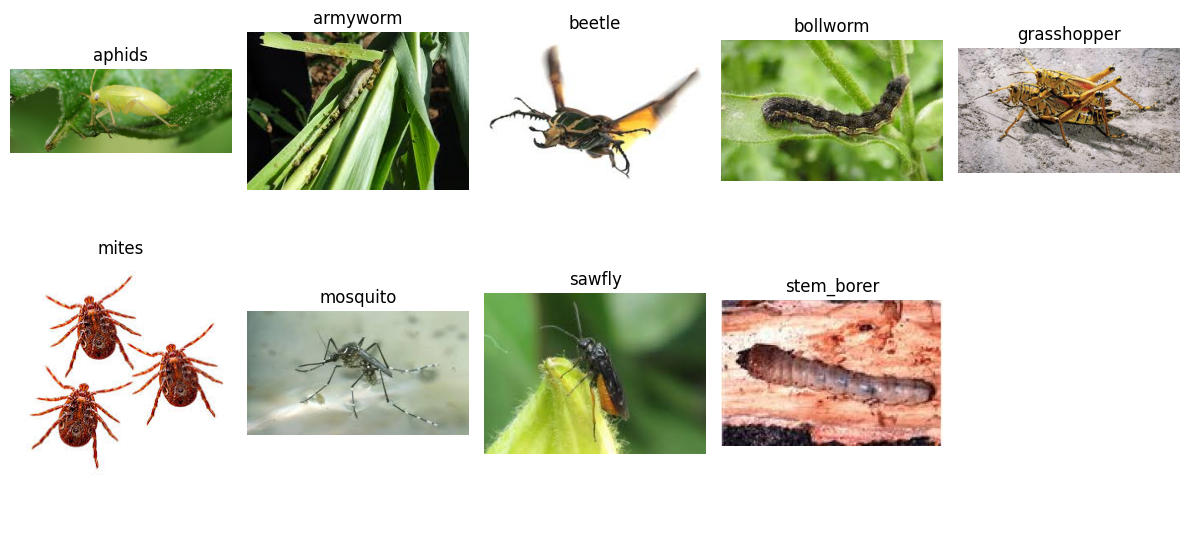

In [10]:
# Displaying a selection of images, one from each class, to visualize the data.
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# Determine grid size
num_cls = len(sel_images)
cols = (num_cls + 1) // 2 # Determine columns
rows = 2 # Fixed rows for layout
fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
  if i < num_cls:
    img = mpimg.imread(sel_images[i])
    ax.imshow(img)
    ax.set_title(sel_labels[i])
    ax.axis("off")
  else:
    ax.axis("off") # Hide empty subplots
plt.tight_layout()
plt.show()

## Data Preprocessing and Generation

In [53]:
# Defining image size and batch size for consistency in model input and training.
IMG_SIZE = 128
BATCH_SIZE = 32

In [54]:
# Creating TensorFlow datasets for training, validation, and testing, with a split for validation.
train_ds = keras.utils.image_dataset_from_directory(
    train_data,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = keras.utils.image_dataset_from_directory(
    train_data,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

test_ds = keras.utils.image_dataset_from_directory(
    test_data,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2094 files belonging to 9 classes.
Using 1676 files for training.
Found 2094 files belonging to 9 classes.
Using 418 files for validation.
Found 384 files belonging to 9 classes.


In [13]:
# Defining data augmentation techniques to introduce variability in training images, preventing overfitting.
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
]

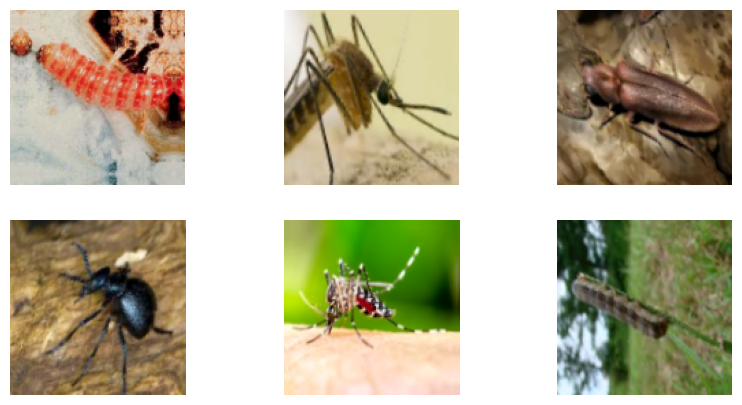

In [14]:
# Visualizing the effects of the defined data augmentation layers on a sample of images.
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10,5))
    for i in range(6):
        ax = plt.subplot(2,3,i+1)
        augmented = images[i]
        for layer in data_augmentation_layers:
            augmented = layer(augmented)
        plt.imshow(augmented.numpy().astype("uint8"))
        plt.axis("off")

In [15]:
# Creating a normalization layer to scale image pixel values from [0, 255] to [0, 1].
normalization_layer = layers.Rescaling(1./255)

In [16]:
# Building our Convolutional Neural Network (CNN) model from scratch.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

num_cls = len(train_ds.class_names)

cnn_model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    *data_augmentation_layers,

    normalization_layer,

    # CNN Layers
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),

    layers.Dense(num_cls, activation='softmax')
])

In [17]:
# Compiling the CNN model with Adam optimizer, sparse categorical crossentropy loss, and accuracy metrics.
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 128, 128, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,315,273 (12.65 MB)

 Trainable params: 3,315,273 (12.65 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Setting up Early Stopping to prevent overfitting and ReduceLROnPlateau to adjust learning rate during training.
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

In [19]:
# Training the CNN model using our prepared datasets and callbacks.
start_time_cnn = time.time()
history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop, lr_scheduler]
)
end_time_cnn = time.time()
cnn_elapsed = end_time_cnn - start_time_cnn
print(f"Training time for CNN Model: {cnn_elapsed:.2f} sec")

Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 156ms/step - accuracy: 0.1879 - loss: 2.1410 - val_accuracy: 0.2440 - val_loss: 2.0597 - learning_rate: 5.0000e-04
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - accuracy: 0.2667 - loss: 2.0290 - val_accuracy: 0.3014 - val_loss: 1.9564 - learning_rate: 5.0000e-04
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 145ms/step - accuracy: 0.3520 - loss: 1.8080 - val_accuracy: 0.3852 - val_loss: 1.7552 - learning_rate: 5.0000e-04
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 143ms/step - accuracy: 0.4266 - loss: 1.6137 - val_accuracy: 0.4019 - val_loss: 1.7131 - learning_rate: 5.0000e-04
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 153ms/step - accuracy: 0.4934 - loss: 1.4520 - val_accuracy: 0.4569 - val_loss: 1.5191 - learning_rate: 5.0000e-04
Epoch 6/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 137ms/step - accuracy: 0.5328 - loss: 1.3435 - val_accuracy: 0.4809 - val_loss: 1.4792 - learning_rate: 5.0000e-04
Epoch 7/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 145ms/step - accuracy

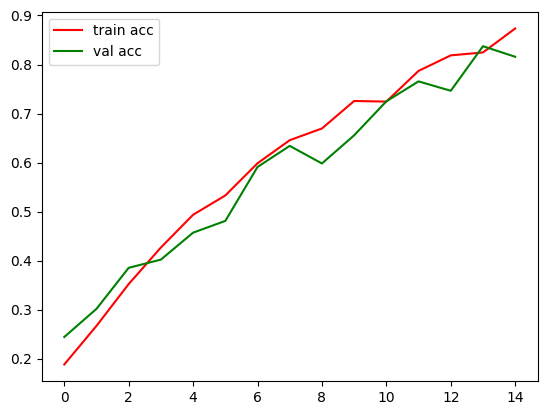

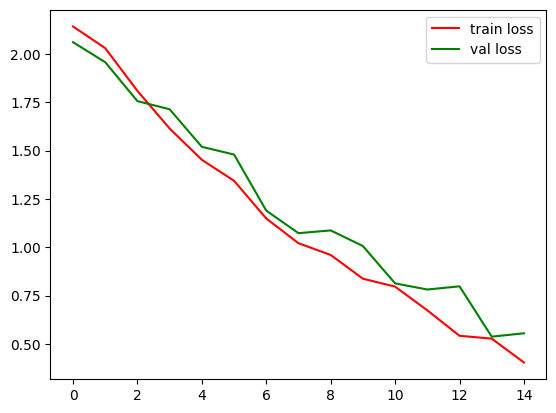

In [20]:
# Plotting the training and validation accuracy and loss over epochs to visualize model performance.
plt.plot(history_cnn.history['accuracy'], label='train acc', color='red')
plt.plot(history_cnn.history['val_accuracy'], label='val acc', color='green')
plt.legend()
plt.show()

plt.plot(history_cnn.history['loss'], label='train loss', color='red')
plt.plot(history_cnn.history['val_loss'], label='val loss', color='green')
plt.legend()
plt.show()

In [21]:
# Evaluating the CNN model's performance on the test dataset and generating a classification report.
import numpy as np
from sklearn.metrics import classification_report

y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

pred = cnn_model.predict(test_ds)
y_pred = np.argmax(pred, axis=1)

classes = test_ds.class_names

print(classification_report(y_true, y_pred, target_names=classes))

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step
              precision    recall  f1-score   support

      aphids       0.78      0.89      0.83        44
    armyworm       0.94      0.77      0.85        43
      beetle       0.89      0.96      0.92        50
    bollworm       0.91      0.86      0.89        36
 grasshopper       0.75      0.98      0.85        46
       mites       0.81      0.71      0.76        42
    mosquito       1.00      0.86      0.92        50
      sawfly       0.68      0.81      0.74        37
  stem_borer       0.89      0.67      0.76        36

    accuracy                           0.84       384
   macro avg       0.85      0.83      0.84       384
weighted avg       0.85      0.84      0.84       384



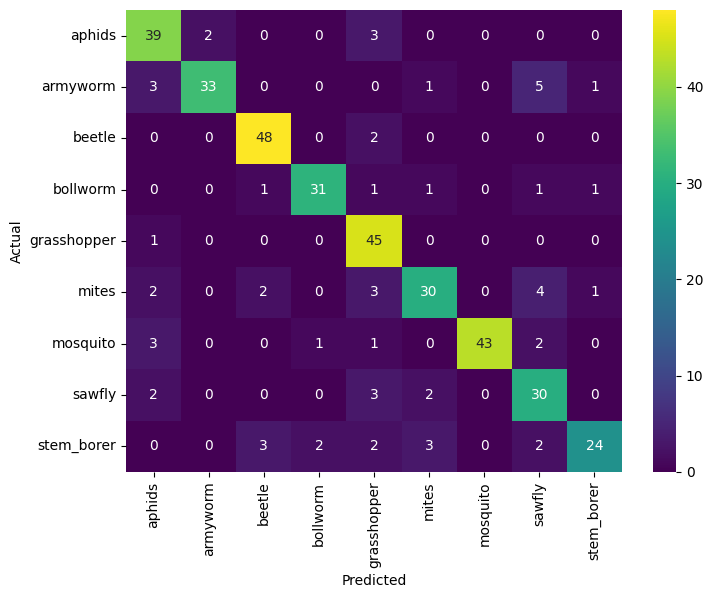

In [22]:
# Creating and visualizing a confusion matrix to understand classification errors.
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='viridis',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Deeper Model

In [55]:
# Defining a more complex CNN model with additional layers, batch normalization, and dropout for improved performance.
from tensorflow import keras
from tensorflow.keras import layers

num_cls = len(train_ds.class_names)

adam_deep_model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    *data_augmentation_layers,

    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.1),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.1),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.1),

    layers.Dense(num_cls, activation='softmax')
])

In [56]:
# Compiling the deeper model with the Adam optimizer.
adam_deep_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

adam_deep_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 128, 128, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 63, 63, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 30, 30, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 2,978,729 (11.36 MB)

 Trainable params: 2,977,257 (11.36 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [57]:
# Re-defining Early Stopping and ReduceLROnPlateau callbacks for the deeper model.
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

In [58]:
# Training the deeper CNN model with Adam optimizer.
start_time_adam_deep = time.time()
history_adam_deep = adam_deep_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, lr_scheduler]
)
end_time_adam_deep = time.time()
adam_deep_elapsed = end_time_adam_deep - start_time_adam_deep
print(f"Training time for Adam Deep Model: {adam_deep_elapsed:.2f} sec")

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 140ms/step - accuracy: 0.2661 - loss: 2.1491 - val_accuracy: 0.1077 - val_loss: 4.6046 - learning_rate: 0.0010
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 164ms/step - accuracy: 0.4159 - loss: 1.7049 - val_accuracy: 0.0766 - val_loss: 4.8884 - learning_rate: 0.0010
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 133ms/step - accuracy: 0.4922 - loss: 1.4616 - val_accuracy: 0.1077 - val_loss: 8.6020 - learning_rate: 0.0010
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 162ms/step - accuracy: 0.5370 - loss: 1.3264 - val_accuracy: 0.1100 - val_loss: 4.5008 - learning_rate: 0.0010
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 159ms/step - accuracy: 0.5883 - loss: 1.1910 - val_accuracy: 0.2033 - val_loss: 2.9870 - learning_rate: 0.0010
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.6557 - loss: 1.0035 - val_accuracy: 0.2416 - val_loss: 2.5391 - learning_rate: 0.0010
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 158ms/step - accuracy: 0.7058 - loss: 0.8929 -

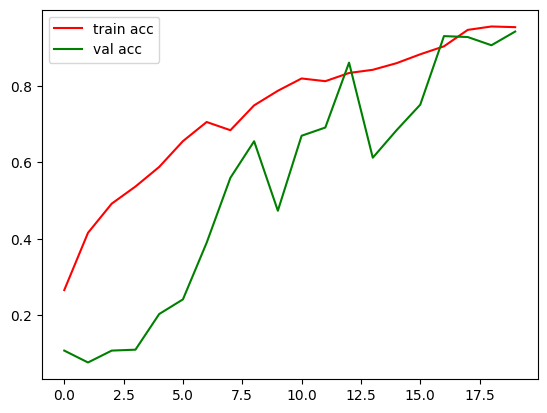

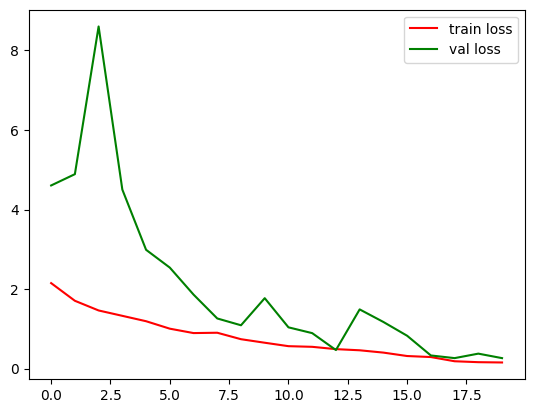

In [59]:
# Plotting the training history for the deeper Adam model.
plt.plot(history_adam_deep.history['accuracy'], label='train acc', color='red')
plt.plot(history_adam_deep.history['val_accuracy'], label='val acc', color='green')
plt.legend()
plt.show()

plt.plot(history_adam_deep.history['loss'], label='train loss', color='red')
plt.plot(history_adam_deep.history['val_loss'], label='val loss', color='green')
plt.legend()
plt.show()

In [60]:
# Evaluating the deeper Adam model on the test dataset.
import numpy as np
from sklearn.metrics import classification_report

y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

pred = adam_deep_model.predict(test_ds)
y_pred = np.argmax(pred, axis=1)

classes = test_ds.class_names

print(classification_report(y_true, y_pred, target_names=classes))

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step
              precision    recall  f1-score   support

      aphids       0.86      1.00      0.93        44
    armyworm       0.95      0.95      0.95        43
      beetle       0.92      0.98      0.95        50
    bollworm       0.95      1.00      0.97        36
 grasshopper       0.98      0.93      0.96        46
       mites       0.95      0.86      0.90        42
    mosquito       1.00      0.96      0.98        50
      sawfly       0.97      0.84      0.90        37
  stem_borer       0.92      0.94      0.93        36

    accuracy                           0.94       384
   macro avg       0.94      0.94      0.94       384
weighted avg       0.95      0.94      0.94       384



SGD

In [29]:
# Defining and compiling another deep CNN model, this time using the SGD optimizer for comparison.
from tensorflow.keras.optimizers import SGD

sgd_deep_model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    *data_augmentation_layers,

    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.1),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.1),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.1),

    layers.Dense(num_cls, activation='softmax')
])


sgd_deep_model.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

sgd_deep_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 128, 128, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 63, 63, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 30, 30, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 2,978,729 (11.36 MB)

 Trainable params: 2,977,257 (11.36 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [30]:
# Re-defining Early Stopping and ReduceLROnPlateau callbacks for the SGD deeper model.
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

In [31]:
# Training the deeper CNN model with SGD optimizer.
start_time_sgd_deep = time.time()
history_sgd_deep = sgd_deep_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop, lr_scheduler]
)
end_time_sgd_deep = time.time()
sgd_deep_elapsed = end_time_sgd_deep - start_time_sgd_deep
print(f"Training time for SGD Deep Model: {sgd_deep_elapsed:.2f} sec")

Epoch 1/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 181ms/step - accuracy: 0.2464 - loss: 2.2425 - val_accuracy: 0.1722 - val_loss: 18.8255 - learning_rate: 0.0100
Epoch 2/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - accuracy: 0.3532 - loss: 1.8597 - val_accuracy: 0.1770 - val_loss: 3.3202 - learning_rate: 0.0100
Epoch 3/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 159ms/step - accuracy: 0.3950 - loss: 1.7162 - val_accuracy: 0.2703 - val_loss: 2.1097 - learning_rate: 0.0100
Epoch 4/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 134ms/step - accuracy: 0.4409 - loss: 1.5854 - val_accuracy: 0.3804 - val_loss: 1.6913 - learning_rate: 0.0100
Epoch 5/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 167ms/step - accuracy: 0.4612 - loss: 1.5069 - val_accuracy: 0.4115 - val_loss: 1.5849 - learning_rate: 0.0100
Epoch 6/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 134ms/step - accuracy: 0.5089 - loss: 1.3859 - val_accuracy: 0.4952 - val_loss: 1.3791 - learning_rate: 0.0100
Epoch 7/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 185ms/step - accuracy: 0.5280 - loss: 1.2966

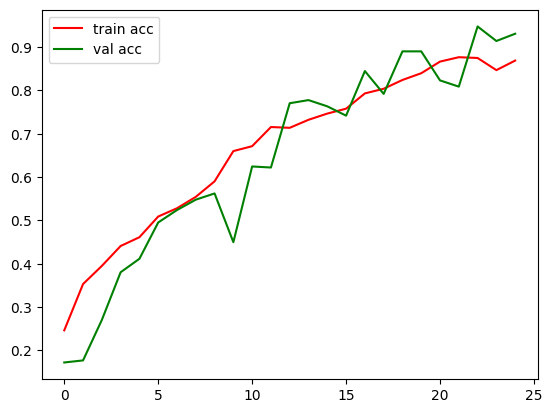

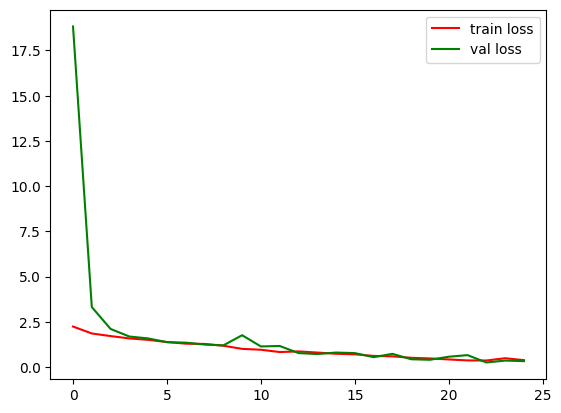

In [32]:
# Plotting the training history for the deeper SGD model.
plt.plot(history_sgd_deep.history['accuracy'], label='train acc', color='red')
plt.plot(history_sgd_deep.history['val_accuracy'], label='val acc', color='green')
plt.legend()
plt.show()

plt.plot(history_sgd_deep.history['loss'], label='train loss', color='red')
plt.plot(history_sgd_deep.history['val_loss'], label='val loss', color='green')
plt.legend()
plt.show()

In [33]:
# Evaluating the deeper SGD model on the test dataset.
sgd_deep_loss, sgd_deep_acc = sgd_deep_model.evaluate(test_ds)
print(f"Test Accuracy for SGD Deep Model: {sgd_deep_acc:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.9401 - loss: 0.3003
Test Accuracy for SGD Deep Model: 0.9401


# Part B: Fine Tuning

In [34]:
# Adjusting image size and recreating datasets for fine-tuning with a pre-trained model.
IMG_SIZE = 224

train_ds = keras.utils.image_dataset_from_directory(
    train_data,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32
)

val_ds = keras.utils.image_dataset_from_directory(
    train_data,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32
)

test_ds = keras.utils.image_dataset_from_directory(
    test_data,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    shuffle=False
)

Found 2094 files belonging to 9 classes.
Using 1676 files for training.
Found 2094 files belonging to 9 classes.
Using 418 files for validation.
Found 384 files belonging to 9 classes.


In [35]:
# Loading the pre-trained MobileNetV2 model as our base, excluding its top classification layer.
base_model = keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [36]:
# Freezing the weights of the base model to prevent them from being updated during initial training.
base_model.trainable = False

In [37]:
# Building our fine-tuning model by adding new classification layers on top of the frozen base model.
num_cls = len(train_ds.class_names)

finetune_model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    *data_augmentation_layers,

    layers.Lambda(keras.applications.mobilenet_v2.preprocess_input),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_cls, activation='softmax')
])

In [38]:
# Compiling the fine-tune model with a specific learning rate for the Adam optimizer.
finetune_model.compile(
    # optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

finetune_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,233 (9.26 MB)

 Trainable params: 167,689 (655.04 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [39]:
# Setting up Early Stopping and learning rate reduction callbacks for the fine-tuning process.
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

In [40]:
# Performing the initial fine-tuning, training only the newly added top layers.
start_time_finetune_initial = time.time()
history_finetune_initial = finetune_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop, lr_scheduler]
)
end_time_finetune_initial = time.time()
finetune_initial_elapsed = end_time_finetune_initial - start_time_finetune_initial
print(f"Training time for Initial Fine-tune Model: {finetune_initial_elapsed:.2f} sec")

Epoch 1/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 18s 224ms/step - accuracy: 0.4779 - loss: 1.7874 - val_accuracy: 0.7368 - val_loss: 0.8830 - learning_rate: 5.0000e-04
Epoch 2/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 173ms/step - accuracy: 0.7440 - loss: 0.7918 - val_accuracy: 0.8565 - val_loss: 0.5450 - learning_rate: 5.0000e-04
Epoch 3/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 153ms/step - accuracy: 0.8264 - loss: 0.5407 - val_accuracy: 0.8923 - val_loss: 0.3996 - learning_rate: 5.0000e-04
Epoch 4/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 173ms/step - accuracy: 0.8598 - loss: 0.4206 - val_accuracy: 0.9067 - val_loss: 0.3220 - learning_rate: 5.0000e-04
Epoch 5/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 177ms/step - accuracy: 0.8807 - loss: 0.3469 - val_accuracy: 0.9115 - val_loss: 0.2734 - learning_rate: 5.0000e-04
Epoch 6/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - accuracy: 0.9254 - loss: 0.2604 - val_accuracy: 0.9306 - val_loss: 0.2436 - learning_rate: 5.0000e-04
Epoch 7/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 173ms/step - accuracy:

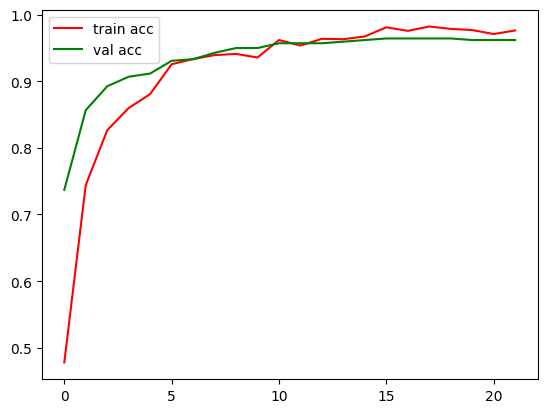

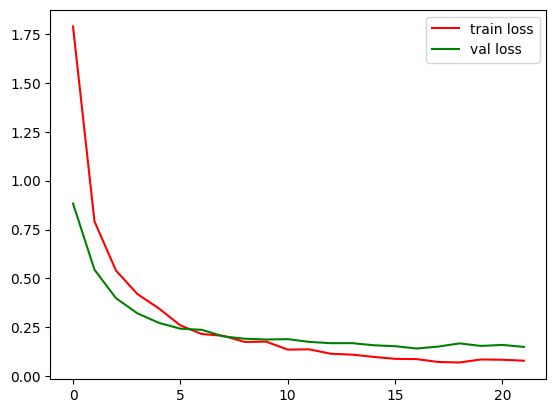

In [41]:
# Plotting the training history from the initial fine-tuning phase.
plt.plot(history_finetune_initial.history['accuracy'], label='train acc', color='red')
plt.plot(history_finetune_initial.history['val_accuracy'], label='val acc', color='green')
plt.legend()
plt.show()

plt.plot(history_finetune_initial.history['loss'], label='train loss', color='red')
plt.plot(history_finetune_initial.history['val_loss'], label='val loss', color='green')
plt.legend()
plt.show()

In [42]:
# Evaluating the fine-tuned model's performance on the test dataset after initial training.
import numpy as np
from sklearn.metrics import classification_report

y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

pred = finetune_model.predict(test_ds)
y_pred = np.argmax(pred, axis=1)

classes = test_ds.class_names

print(classification_report(y_true, y_pred, target_names=classes))

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 133ms/step
              precision    recall  f1-score   support

      aphids       0.94      1.00      0.97        44
    armyworm       1.00      0.98      0.99        43
      beetle       1.00      0.98      0.99        50
    bollworm       0.97      1.00      0.99        36
 grasshopper       0.96      1.00      0.98        46
       mites       0.98      1.00      0.99        42
    mosquito       1.00      0.98      0.99        50
      sawfly       0.97      0.84      0.90        37
  stem_borer       0.92      0.94      0.93        36

    accuracy                           0.97       384
   macro avg       0.97      0.97      0.97       384
weighted avg       0.97      0.97      0.97       384



In [43]:
# Unfreezing some layers of the base model for further fine-tuning with a very small learning rate.
base_model.trainable = True

# Freeze lower layers, train only top layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [44]:
# Re-compiling the fine-tune model with a much smaller learning rate to avoid disrupting pre-trained weights.
finetune_model.compile(
    # optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [45]:
# Re-setting Early Stopping and learning rate reduction callbacks for the final fine-tuning phase.
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

In [46]:
# Performing the final fine-tuning phase, training both the top layers and some unfrozen base model layers.
start_time_finetune_final = time.time()
history_finetune_final = finetune_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, lr_scheduler]
)
end_time_finetune_final = time.time()
finetune_final_elapsed = end_time_finetune_final - start_time_finetune_final
print(f"Training time for Final Fine-tune Model: {finetune_final_elapsed:.2f} sec")

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 21s 208ms/step - accuracy: 0.8675 - loss: 0.4258 - val_accuracy: 0.7608 - val_loss: 1.2948 - learning_rate: 5.0000e-04
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 181ms/step - accuracy: 0.9350 - loss: 0.2320 - val_accuracy: 0.7751 - val_loss: 1.8579 - learning_rate: 5.0000e-04
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 173ms/step - accuracy: 0.9463 - loss: 0.1747 - val_accuracy: 0.7799 - val_loss: 1.6732 - learning_rate: 5.0000e-04
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 180ms/step - accuracy: 0.9600 - loss: 0.1354 - val_accuracy: 0.7967 - val_loss: 1.6568 - learning_rate: 5.0000e-04
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 175ms/step - accuracy: 0.9779 - loss: 0.0628 - val_accuracy: 0.8565 - val_loss: 1.0264 - learning_rate: 2.5000e-04
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - accuracy: 0.9797 - loss: 0.0709 - val_accuracy: 0.8278 - val_loss: 1.1881 - learning_rate: 2.5000e-04
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 202ms/step - accura

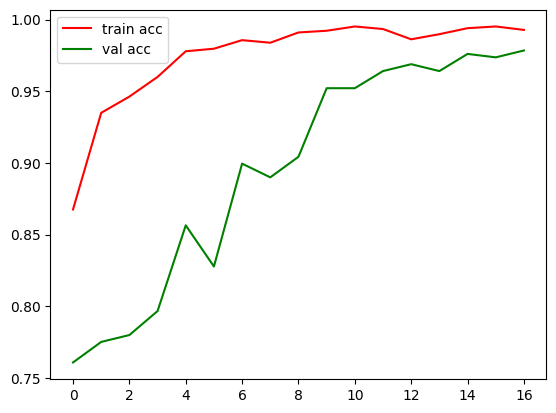

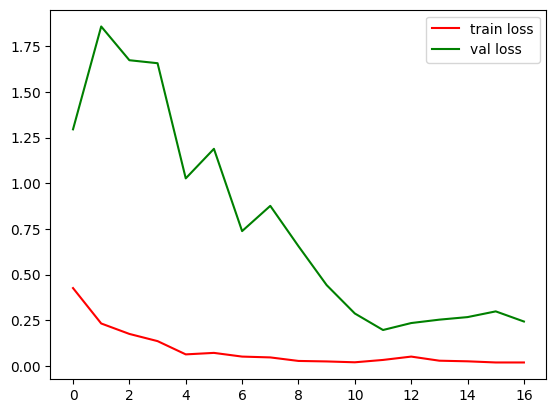

In [47]:
# Plotting the training history from the final fine-tuning phase.
plt.plot(history_finetune_final.history['accuracy'], label='train acc', color='red')
plt.plot(history_finetune_final.history['val_accuracy'], label='val acc', color='green')
plt.legend()
plt.show()

plt.plot(history_finetune_final.history['loss'], label='train loss', color='red')
plt.plot(history_finetune_final.history['val_loss'], label='val loss', color='green')
plt.legend()
plt.show()

In [48]:
# Generating a final classification report for the fine-tuned model on the test dataset.
import numpy as np
from sklearn.metrics import classification_report

y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

pred = finetune_model.predict(test_ds)
y_pred = np.argmax(pred, axis=1)

class_names = test_ds.class_names

print(classification_report(y_true, y_pred, target_names=class_names))

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step
              precision    recall  f1-score   support

      aphids       0.90      1.00      0.95        44
    armyworm       1.00      0.79      0.88        43
      beetle       1.00      1.00      1.00        50
    bollworm       0.95      1.00      0.97        36
 grasshopper       0.94      1.00      0.97        46
       mites       1.00      1.00      1.00        42
    mosquito       1.00      1.00      1.00        50
      sawfly       0.89      0.92      0.91        37
  stem_borer       1.00      0.94      0.97        36

    accuracy                           0.96       384
   macro avg       0.96      0.96      0.96       384
weighted avg       0.97      0.96      0.96       384



In [49]:
# Displaying the overall test accuracy of the final fine-tuned model.
loss, acc = finetune_model.evaluate(test_ds)
print(f"Final Fine-tuned Model Test Accuracy: {acc:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.9635 - loss: 0.2830
Final Fine-tuned Model Test Accuracy: 0.9635


In [50]:
# Re-printing the final classification report for comprehensive evaluation.
import numpy as np
from sklearn.metrics import classification_report

y_true = []
for _, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

pred = finetune_model.predict(test_ds)
y_pred = np.argmax(pred, axis=1)

print(classification_report(y_true, y_pred, target_names=test_ds.class_names))

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step
              precision    recall  f1-score   support

      aphids       0.90      1.00      0.95        44
    armyworm       1.00      0.79      0.88        43
      beetle       1.00      1.00      1.00        50
    bollworm       0.95      1.00      0.97        36
 grasshopper       0.94      1.00      0.97        46
       mites       1.00      1.00      1.00        42
    mosquito       1.00      1.00      1.00        50
      sawfly       0.89      0.92      0.91        37
  stem_borer       1.00      0.94      0.97        36

    accuracy                           0.96       384
   macro avg       0.96      0.96      0.96       384
weighted avg       0.97      0.96      0.96       384



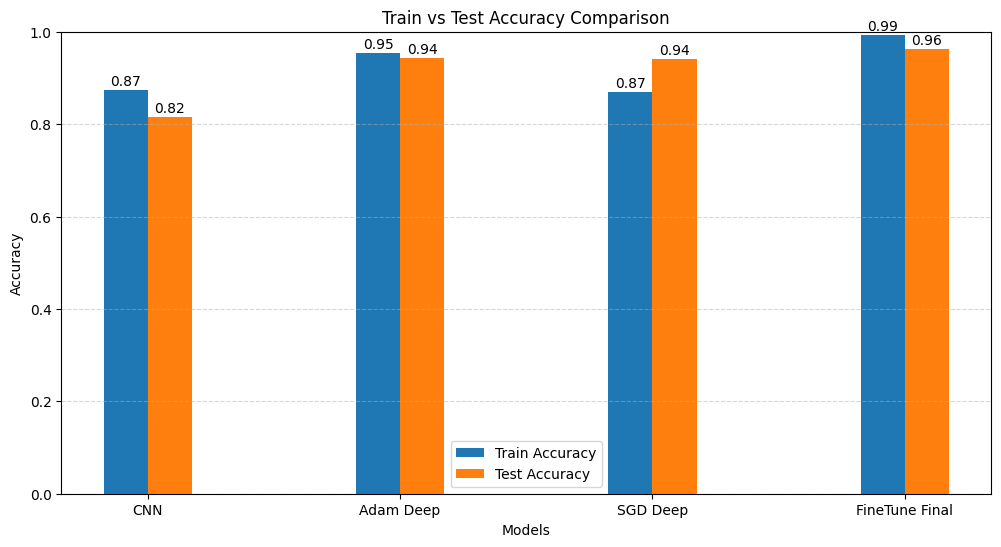

In [61]:
import matplotlib.pyplot as plt
import numpy as np

model_results = {
    "CNN": {
        "train_acc": history_cnn.history['accuracy'][-1],
        "test_acc": history_cnn.history['val_accuracy'][-1]
    },

    "Adam Deep": {
        "train_acc": history_adam_deep.history['accuracy'][-1],
        "test_acc": history_adam_deep.history['val_accuracy'][-1]
    },

    "SGD Deep": {
        "train_acc": history_sgd_deep.history['accuracy'][-1],
        "test_acc": sgd_deep_acc
    },

    "FineTune Final": {
        "train_acc": history_finetune_final.history['accuracy'][-1],
        "test_acc": acc
    }
}

models = list(model_results.keys())

train_acc = [
    model_results[model]["train_acc"]
    for model in models
]

test_acc = [
    model_results[model]["test_acc"]
    for model in models
]

x = np.arange(len(models)) * 2
width = 0.35

plt.figure(figsize=(12,6))

plt.bar(
    x - width/2,
    train_acc,
    width=width,
    label='Train Accuracy'
)

plt.bar(
    x + width/2,
    test_acc,
    width=width,
    label='Test Accuracy'
)

plt.xticks(x, models)
plt.ylim(0, 1)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy Comparison")

for i in range(len(models)):

    plt.text(
        x[i] - width/2,
        train_acc[i] + 0.01,
        f"{train_acc[i]:.2f}",
        ha='center'
    )

    plt.text(
        x[i] + width/2,
        test_acc[i] + 0.01,
        f"{test_acc[i]:.2f}",
        ha='center'
    )

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
